# Computer Vision Architectures - CNN & ViT
---

## Abstract 
On this project I tried to implement from scratch 2 types of computer vision classifier architectures : Convolutional Neural Networks & Vision Transformer. 
I trained and tested the models on the CIFAR-10 dataset composed of 60k images and 10 different classes.


/users/eleves-a/2024/etienne.chevrolat/Documents/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


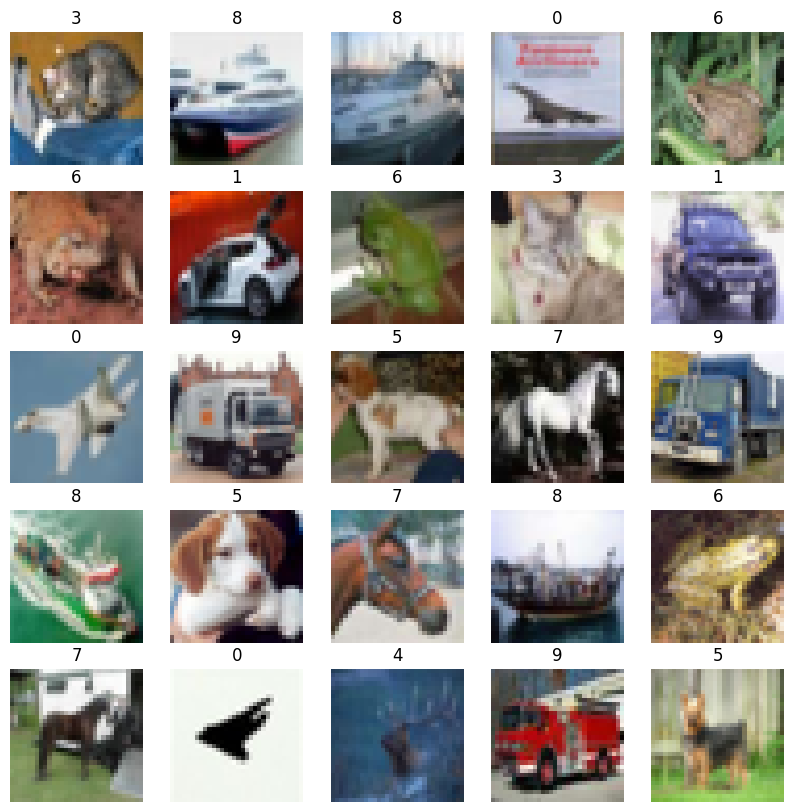

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## Dataset
test_data = datasets.CIFAR10(root="./dataset", train=False, download=True, transform=transforms.ToTensor())


plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(test_data[i][0].permute(1, 2, 0))
    plt.title(test_data[i][1])
    plt.axis("off")
plt.show()

## Convolutional Neural Networks 


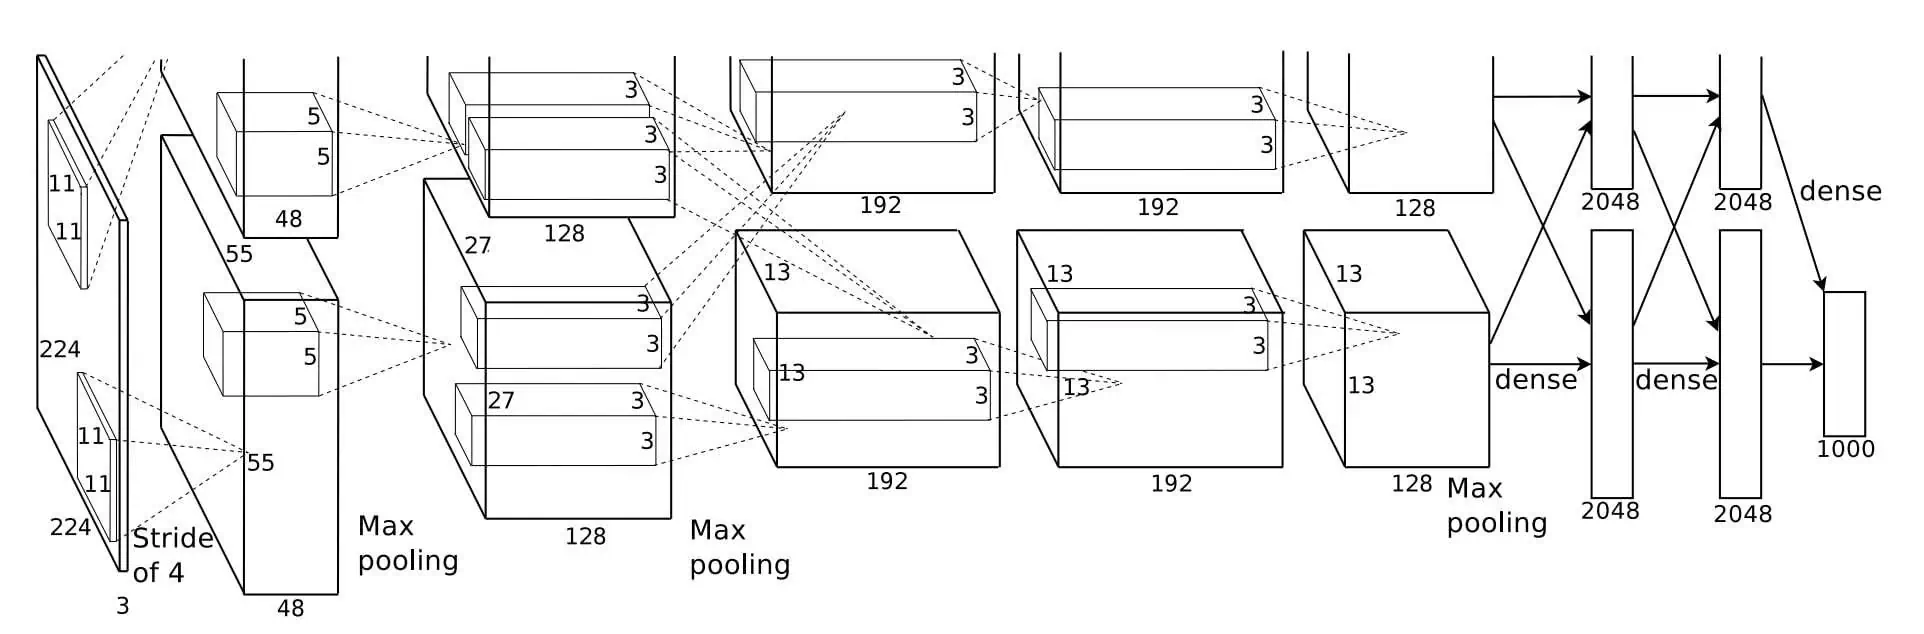

In this project, I have built five CNN : 
CNN1, 
CNN2, 
CNN3, CNN4, below are the final results. 

The training was made with the same hyperparameters for the 5 models : 

Optimizer : Adam 

Epochs : 50 

Learning rate : 1e-3

Batch size : 64

### Number of Parameters 
---
#### CNN1
**Total parameters:** 14,578  
Small baseline CNN with moderate feature extraction capacity.

#### CNN3
**Total parameters:** 5,558  
Very compact CNN using smaller convolution filters (3×3).


#### CNN4
**Total parameters:** 41,274  
Single convolution layer followed by a large fully connected layer, leading to higher parameter count.

#### LeNet 
**Total parameters:** 83,126  
Classic CNN architecture with fully connected layers, serving as a strong baseline.

#### MyCNN - Custom model (inspired by ResNet)
**Total parameters:** 1,164,586  
Deep CNN with residual connections, higher channel depth, and dropout regularization.

- Lightweight CNNs (<15k parameters) are useful for studying architectural sensitivity (depth, kernel size).
- Fully connected layers significantly increase parameter count (e.g., CNN4).
- Deeper architectures with higher channel widths (MyCNN) drastically increase model capacity and complexity.

In [2]:

import sys
sys.path.insert(0, '..')

from torch.utils.data import DataLoader
from src.cnn.models import mycnn, LeNet, CNN1, CNN2, CNN3, CNN4
from src.vit.utils_vit.vision_transformer import ViT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


In [ ]:

MODEL_DICT = {
    'mycnn_v1': mycnn,
    'lenet': LeNet,
    'cnn1': CNN1,
    'cnn2': CNN2,
    'cnn3': CNN3,
    'cnn4': CNN4
}

def cnn_test(model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    test_data = datasets.CIFAR10(root="./dataset", train=False, download=True, transform=transform)
    test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

    model = MODEL_DICT[model_name]().to(device)

    state_dict = torch.load(f'../data/models/{model_name}.pth', map_location=device)
    model.load_state_dict(state_dict)

    model.eval()


    correct = 0
    total = 0  
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()   
    print(f"Précision du modèle {model_name} sur le jeu de test : {100 * correct / total:.2f}%")

for model_name in MODEL_DICT.keys():
    cnn_test(model_name)


Précision du modèle mycnn_v1 sur le jeu de test : 78.27%
Précision du modèle lenet sur le jeu de test : 69.05%
Précision du modèle cnn1 sur le jeu de test : 62.21%
Précision du modèle cnn2 sur le jeu de test : 50.86%
Précision du modèle cnn3 sur le jeu de test : 52.90%
Précision du modèle cnn4 sur le jeu de test : 53.08%


![Screenshot 1](../figures/training_results_3.png)

## Vision Transformer 

![Screenshot 3](../figures/vision_transformer.png)

I have built the backbone of th ViT from scratch and trained it with the parameters as follows : 

img_size=32

patch_size=4

hidden_dim=128

n_heads=8

n_layers=12

dropout_rate=0.1

--- 
Optimizer : AdamW (variant of Adam)

Epochs = 100

Batch size = 64

Learning rate = 3e-4 (lower learning rate for ViTs)

![Screenshot 4](../figures/training_results_9.png)

While the CNNs appears to converge to a certain loss, the ViT is still learning as the epochs go by and finally outperform the CNNs at first sight


In [4]:

def vit_test():
    model = ViT(img_size=32, patch_size=4, hidden_dim=128, n_heads=8, n_layers=12, dropout_rate=0.1).to(device)

    state_dict = torch.load(f'../data/models/vit1.pth', map_location=device)
    model.load_state_dict(state_dict)

    model.eval()


    correct = 0
    total = 0  
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()   
    print(f"Précision du modèle vit1 sur le jeu de test : {100 * correct / total:.2f}%")

vit_test()


Précision du modèle vit1 sur le jeu de test : 74.02%


### Number of Parameters — Vision Transformer


| Component | Parameters |
|----------|------------|
| Patch Embedding | ~6K |
| Positional Encoding | ~8K |
| Transformer Encoder (12 layers) | ~2.23M |
| Classification Head | ~1K |
| Class Token | ~0.1K |
| **Total** | **~2.26M** |


The majority of parameters (~99%) are concentrated in the Transformer encoder blocks.



## Conclusion

In this project, we implemented and compared Convolutional Neural Networks and a Vision Transformer (ViT) on the CIFAR-10 dataset. The goal was to evaluate how these two architectures differ in terms of learning behavior, performance, and parameter efficiency when trained under the same conditions.

The CNN models here achieved better and more stable performance than the ViT. The custom CNN converged faster and reached higher test accuracy of 78% despite having fewer parameters. In contrast, the Vision Transformer achieved a lower accuracy of around 74%.

Performance gap ? It can be explained primarily by the characteristics of the CIFAR-10 dataset. It is relatively small for transformer-based models, which typically require large-scale datasets to fully learn meaningful attention patterns. CNNs, on the other hand, benefit from strong inductive biases such as locality and translation invariance, making them more suitable for limited data regimes.

ViTs are more sensitive to training conditions and generally require longer training, stronger regularization, or pretraining on larger datasets to perform optimally. In this project, the models were trained from scratch under identical constraints, which further favored CNNs.

---

To go further and have better results : 

Data augmentation ?

Training on bigger datasets ?  ImageNet (600M images of size 224*224)

BatchNorm on CNN ? 